## RAPIDAPI

In [2]:

import requests

url = "https://betsapi2.p.rapidapi.com/v3/bet365/prematch"

querystring = {"FI":""}

headers = {
	"X-RapidAPI-Key": "704d35bb14mshd7e026982fa4bcdp1b26ffjsn10fa9b163c5f",
	"X-RapidAPI-Host": "betsapi2.p.rapidapi.com"
}

response = requests.request("GET", url, headers=headers)

print(response.text)

{"success":0,"error":"PARAM_INVALID","error_detail":"FI"}


In [87]:
import pandas as pd

def get_league_name(search = ""):

    """ Rule of thumb is to use the country you are interested in as the first search term"""
    
    legend = pd.read_json("league_id_to_name.json", orient="index")
    legend = legend.reset_index()
    legend.columns = ["Key", "leagues"]
    legend = legend.set_index('leagues')
    df = legend.filter(like=search, axis = 0)
    print(df.to_dict(orient="dict")['Key'])

In [92]:
get_league_name("England")

{'England Premier League': 10041282, 'England Championship': 10041101, 'England FA Cup Qualification': 10041294, 'England League 1': 10036537, 'England League 2': 10041336, 'England National League': 10040381, 'England Northern Premier League': 10040383, 'England Southern Premier League Central': 10040387, 'England Southern Premier League South': 10040388, 'England National League North': 10041337, 'England National League South': 10041342, 'England Development League 2': 10075302, 'England EFL Cup': 10042428, 'England Southern League Division One': 10040085, 'England Isthmian Cup': 10040386, 'England Northern League Division One': 10043595}


-- League_id 

Ecuador -- 10079446


In [121]:
import requests

url = "https://api-football-v1.p.rapidapi.com/v3/fixtures"
#url = "https://api-football-v1.p.rapidapi.com/v3/fixtures"

#querystring = {"from": "2024-04-11", "to":"2024-04-13"}
querystring = {"date":"2021-04-11"}

headers = {
	"X-RapidAPI-Key": "704d35bb14mshd7e026982fa4bcdp1b26ffjsn10fa9b163c5f",
	"X-RapidAPI-Host": "api-football-v1.p.rapidapi.com"
}

response = requests.get(url, headers=headers, params=querystring)

v = response.json()
print(v)

{'get': 'fixtures', 'parameters': {'date': '2021-04-11'}, 'errors': [], 'results': 1435, 'paging': {'current': 1, 'total': 1}, 'response': [{'fixture': {'id': 580295, 'referee': None, 'timezone': 'UTC', 'date': '2021-04-11T00:00:00+00:00', 'timestamp': 1618099200, 'periods': {'first': None, 'second': None}, 'venue': {'id': 8060, 'name': 'Centre Sportif des Rojalets', 'city': 'Coppet'}, 'status': {'long': 'Match Cancelled', 'short': 'CANC', 'elapsed': None}}, 'league': {'id': 599, 'name': '1. Liga Classic - Group 1', 'country': 'Switzerland', 'logo': 'https://media.api-sports.io/football/leagues/599.png', 'flag': 'https://media.api-sports.io/flags/ch.svg', 'season': 2020, 'round': 'Group 1 - 19'}, 'teams': {'home': {'id': 12696, 'name': 'Terre Sainte', 'logo': 'https://media.api-sports.io/football/teams/12696.png', 'winner': None}, 'away': {'id': 12693, 'name': 'Lausanne Sport II', 'logo': 'https://media.api-sports.io/football/teams/12693.png', 'winner': None}}, 'goals': {'home': None, 

In [119]:
v['response'][0].keys()

TypeError: 'int' object is not subscriptable

In [122]:
teams=  {}
fixture_id = {}
venue_key = {}
league_key = {}

for item in v['response']:
    venue_key[item['fixture']['venue']['name']] = item['fixture']['venue']['id']
    league_key[item['league']['name']] = item['league']['id']
    #country = item['fixture']['country']
    teams[item['teams']['home']['name']] = item['teams']['home']['id']
    teams[item['teams']['away']['name']] = item['teams']['away']['id']
    fixture_id[item['fixture']['id']] = (item['teams']['home']['id'],item['teams']['away']['id'])

In [123]:
print(fixture_id)

{580295: (12696, 12693), 580296: (12695, 6628), 580297: (6618, 12697), 580298: (12698, 6623), 580477: (12702, 12701), 580478: (12705, 12708), 580479: (12700, 12703), 580480: (12704, 6614), 580657: (6629, 12721), 580658: (12713, 12711), 580660: (12717, 6638), 580661: (12718, 12712), 635479: (803, 521), 652923: (2295, 2278), 653981: (821, 815), 671046: (16321, 16323), 671047: (6631, 16326), 671048: (6644, 16325), 671049: (16319, 16317), 671050: (16322, 14608), 671051: (16320, 16318), 671211: (16331, 16330), 671212: (16338, 16334), 671213: (16333, 16339), 671214: (16327, 16336), 671215: (16337, 16332), 671216: (16328, 16335), 671384: (16344, 6645), 671385: (14601, 12753), 671386: (16345, 16342), 671387: (16348, 16340), 671566: (16351, 16359), 671567: (16358, 16354), 671568: (16349, 16350), 671569: (16352, 6648), 671570: (6647, 6626), 671731: (16368, 16367), 671732: (16364, 16365), 671733: (6640, 6632), 671734: (14607, 16360), 671735: (16366, 6625), 671889: (16374, 16371), 671890: (16370, 

In [112]:
import requests

url = "https://api-football-v1.p.rapidapi.com/v3/predictions"
querystring = {"fixture":"580297"}

headers = {
	"X-RapidAPI-Key": "704d35bb14mshd7e026982fa4bcdp1b26ffjsn10fa9b163c5f",
	"X-RapidAPI-Host": "api-football-v1.p.rapidapi.com"
}

response = requests.get(url, headers=headers, params=querystring)

w = response.json()
print(w)

{'get': 'predictions', 'parameters': {'fixture': '580297'}, 'errors': [], 'results': 1, 'paging': {'current': 1, 'total': 1}, 'response': [{'predictions': {'winner': {'id': 6618, 'name': 'Bulle', 'comment': None}, 'win_or_draw': False, 'under_over': '+2.5', 'goals': {'home': '-5.5', 'away': '-2.5'}, 'advice': 'Combo Winner : Bulle and +2.5 goals', 'percent': {'home': '45%', 'draw': '45%', 'away': '10%'}}, 'league': {'id': 599, 'name': '1. Liga Classic - Group 1', 'country': 'Switzerland', 'logo': 'https://media.api-sports.io/football/leagues/599.png', 'flag': 'https://media.api-sports.io/flags/ch.svg', 'season': 2020}, 'teams': {'home': {'id': 6618, 'name': 'Bulle', 'logo': 'https://media.api-sports.io/football/teams/6618.png', 'last_5': {'played': 5, 'form': '47%', 'att': '63%', 'def': '50%', 'goals': {'for': {'total': 15, 'average': '3.0'}, 'against': {'total': 12, 'average': '2.4'}}}, 'league': {'form': 'WWWWDWLL', 'fixtures': {'played': {'home': 4, 'away': 4, 'total': 8}, 'wins': {

In [124]:
for i, j in teams.items():
    if j == 12697:
        print(i)

Vevey Sports


In [119]:
import pandas as pd
import pprint as pp

In [125]:
upcoming_events = response.json()
pp.pprint(upcoming_events)

{'pager': {'page': 1, 'per_page': 50, 'total': 3},
 'results': [{'away': {'id': '10360919', 'name': 'Independiente Juniors'},
              'home': {'id': '10431793', 'name': 'Imbabura'},
              'id': '143683145',
              'league': {'id': '10079446', 'name': 'Ecuador LigaPro Serie B'},
              'our_event_id': '6362428',
              'r_id': '143683145C1A',
              'sport_id': '1',
              'ss': '0-3',
              'time': '1695772800',
              'time_status': '3',
              'updated_at': '1695779895'},
             {'away': {'id': '10409757', 'name': 'America de Quito'},
              'home': {'id': '10863803', 'name': 'Buhos ULVR'},
              'id': '143683147',
              'league': {'id': '10079446', 'name': 'Ecuador LigaPro Serie B'},
              'our_event_id': '6362427',
              'r_id': None,
              'sport_id': '1',
              'ss': None,
              'time': '1695844800',
              'time_status': '0',
        

In [123]:
upcoming_events['pager']['page']

1

## ODDS API
Link : https://the-odds-api.com/sports-odds-data/betting-markets.html

In [4]:
import pandas as pd
import requests

API_KEY = '063f071248d271d8b3c1a47bc38af038'
sports = ''
region = 'us'
markets = 'totals', 'h2h', 'spreads', 'alternate_spreads', 'alternate_totals', 'btts', 'h2h_3_way', 'draw_no_bet'


url = f'https://api.the-odds-api.com/v4/sports/soccer_spain_la_liga/odds/?apiKey={API_KEY}&regions=us&markets=totals,h2h,alternate_totals,btts'
h2h_url = f'https://api.the-odds-api.com/v4/sports/upcoming/odds/?apiKey={API_KEY}&regions=us&markets=h2h'
sport_url = f'https://api.the-odds-api.com/v4/sports/?apiKey={API_KEY}'

#/v4/sports/{sport}/odds/?apiKey={apiKey}&regions={regions}&markets={markets}

In [3]:
sports = requests.get(url= sport_url)
sports.json()

league_keys = []
for item in sports.json():
    league_keys.append(item['key'])

NameError: name 'requests' is not defined



'soccer_england_league1',
'soccer_england_league2',

In [94]:
league_keys

['americanfootball_cfl',
 'americanfootball_ncaaf',
 'americanfootball_nfl',
 'americanfootball_nfl_super_bowl_winner',
 'aussierules_afl',
 'baseball_mlb',
 'baseball_mlb_world_series_winner',
 'basketball_nba',
 'basketball_nba_championship_winner',
 'basketball_wnba',
 'boxing_boxing',
 'cricket_odi',
 'golf_masters_tournament_winner',
 'golf_pga_championship_winner',
 'golf_us_open_winner',
 'icehockey_nhl_championship_winner',
 'icehockey_sweden_allsvenskan',
 'icehockey_sweden_hockey_league',
 'mma_mixed_martial_arts',
 'rugbyleague_nrl',
 'rugbyunion_world_cup',
 'soccer_australia_aleague',
 'soccer_austria_bundesliga',
 'soccer_belgium_first_div',
 'soccer_brazil_campeonato',
 'soccer_brazil_serie_b',
 'soccer_chile_campeonato',
 'soccer_china_superleague',
 'soccer_conmebol_copa_libertadores',
 'soccer_denmark_superliga',
 'soccer_efl_champ',
 'soccer_england_efl_cup',
 'soccer_england_league1',
 'soccer_england_league2',
 'soccer_epl',
 'soccer_finland_veikkausliiga',
 'socce

### h2h

In [65]:
h2h_state = requests.get(url = h2h_url)

In [67]:
h2h_state.json()

[{'id': 'a311587dca7b9ebaf6307aa4f9cdce0d',
  'sport_key': 'cricket_odi',
  'sport_title': 'One Day Internationals',
  'commence_time': '2023-09-27T08:00:00Z',
  'home_team': 'India',
  'away_team': 'Australia',
  'bookmakers': [{'key': 'unibet_us',
    'title': 'Unibet',
    'last_update': '2023-09-27T08:39:23Z',
    'markets': [{'key': 'h2h',
      'last_update': '2023-09-27T08:39:23Z',
      'outcomes': [{'name': 'Australia', 'price': 1.34},
       {'name': 'India', 'price': 3.25}]}]},
   {'key': 'draftkings',
    'title': 'DraftKings',
    'last_update': '2023-09-27T08:39:22Z',
    'markets': [{'key': 'h2h',
      'last_update': '2023-09-27T08:39:22Z',
      'outcomes': [{'name': 'Australia', 'price': 1.37},
       {'name': 'India', 'price': 3.1}]}]}]},
 {'id': '4bc207791fa6d7910646ab4db11cbcb8',
  'sport_key': 'soccer_greece_super_league',
  'sport_title': 'Super League - Greece',
  'commence_time': '2023-09-27T13:00:00Z',
  'home_team': 'Panetolikos Agrinio',
  'away_team': 'OFI 

In [96]:
state = requests.get(url= url)
state.json()

[{'id': '223ef8e876c644ce0484e952f62b2d0c',
  'sport_key': 'soccer_spain_la_liga',
  'sport_title': 'La Liga - Spain',
  'commence_time': '2023-09-27T17:00:00Z',
  'home_team': 'Athletic Bilbao',
  'away_team': 'Getafe',
  'bookmakers': [{'key': 'mybookieag',
    'title': 'MyBookie.ag',
    'last_update': '2023-09-27T09:36:33Z',
    'markets': [{'key': 'h2h',
      'last_update': '2023-09-27T09:36:33Z',
      'outcomes': [{'name': 'Athletic Bilbao', 'price': 1.64},
       {'name': 'Getafe', 'price': 6.0},
       {'name': 'Draw', 'price': 3.65}]},
     {'key': 'totals',
      'last_update': '2023-09-27T09:36:33Z',
      'outcomes': [{'name': 'Over', 'price': 2.35, 'point': 2.5},
       {'name': 'Under', 'price': 1.58, 'point': 2.5}]}]},
   {'key': 'fanduel',
    'title': 'FanDuel',
    'last_update': '2023-09-27T09:37:39Z',
    'markets': [{'key': 'h2h',
      'last_update': '2023-09-27T09:37:39Z',
      'outcomes': [{'name': 'Athletic Bilbao', 'price': 1.59},
       {'name': 'Getafe', 

In [68]:
h2h = pd.DataFrame(h2h_state.json())

In [74]:
h2h = h2h_state.json()
for item in h2h:
    if item['bookmakers']:
        print(item['bookmakers'])

[{'key': 'unibet_us', 'title': 'Unibet', 'last_update': '2023-09-27T08:39:23Z', 'markets': [{'key': 'h2h', 'last_update': '2023-09-27T08:39:23Z', 'outcomes': [{'name': 'Australia', 'price': 1.34}, {'name': 'India', 'price': 3.25}]}]}, {'key': 'draftkings', 'title': 'DraftKings', 'last_update': '2023-09-27T08:39:22Z', 'markets': [{'key': 'h2h', 'last_update': '2023-09-27T08:39:22Z', 'outcomes': [{'name': 'Australia', 'price': 1.37}, {'name': 'India', 'price': 3.1}]}]}]
[{'key': 'mybookieag', 'title': 'MyBookie.ag', 'last_update': '2023-09-27T08:38:40Z', 'markets': [{'key': 'h2h', 'last_update': '2023-09-27T08:38:40Z', 'outcomes': [{'name': 'OFI Crete', 'price': 2.42}, {'name': 'Panetolikos Agrinio', 'price': 3.05}, {'name': 'Draw', 'price': 3.15}]}]}, {'key': 'fanduel', 'title': 'FanDuel', 'last_update': '2023-09-27T08:39:50Z', 'markets': [{'key': 'h2h', 'last_update': '2023-09-27T08:39:50Z', 'outcomes': [{'name': 'OFI Crete', 'price': 2.35}, {'name': 'Panetolikos Agrinio', 'price': 2.9

In [83]:
h2h_state.headers

{'Date': 'Wed, 27 Sep 2023 08:39:56 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Content-Length': '1967', 'Connection': 'keep-alive', 'X-Requests-Used': '4', 'X-Requests-Remaining': '496', 'vary': 'Accept-Encoding', 'content-encoding': 'gzip', 'Apigw-Requestid': 'L6GOjhCvIAMEMLg='}

In [97]:
df = pd.DataFrame(state.json())
df

,id,sport_key,sport_title,commence_time,home_team,away_team,bookmakers
0,223ef8e876c644ce0484e952f62b2d0c,soccer_spain_la_liga,La Liga - Spain,2023-09-27T17:00:00Z,Athletic Bilbao,Getafe,"[{'key': 'mybookieag', 'title': 'MyBookie.ag',..."
1,76e465483b576e9ae880a010e0f9b037,soccer_spain_la_liga,La Liga - Spain,2023-09-27T17:00:00Z,Villarreal,Girona,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."
2,9282af9cf4e84682a2cd6532c928e0ab,soccer_spain_la_liga,La Liga - Spain,2023-09-27T17:00:00Z,Real Madrid,Las Palmas,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."
3,0867e0272f8be73f260366a156cfb2ed,soccer_spain_la_liga,La Liga - Spain,2023-09-27T19:30:00Z,Cádiz CF,Rayo Vallecano,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."
4,dd36f04b8b6b415266888d611bdfa351,soccer_spain_la_liga,La Liga - Spain,2023-09-27T19:30:00Z,Valencia,Real Sociedad,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."
5,1203f211996ddce5249b96e72362d3ea,soccer_spain_la_liga,La Liga - Spain,2023-09-28T17:00:00Z,Celta Vigo,Alavés,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."
6,7fce98a1c52052f080ba32a28a3e7d8e,soccer_spain_la_liga,La Liga - Spain,2023-09-28T17:00:00Z,Granada CF,Real Betis,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."
7,02896fae04ac26a53e36f7cab062261f,soccer_spain_la_liga,La Liga - Spain,2023-09-28T19:30:00Z,CA Osasuna,Atlético Madrid,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."
8,1c7f6d634fc0b2c381ac5fd61353da14,soccer_spain_la_liga,La Liga - Spain,2023-09-29T19:00:00Z,Barcelona,Sevilla,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."
9,5cb267df928c3500cfc7cea68c9ff22b,soccer_spain_la_liga,La Liga - Spain,2023-09-30T12:00:00Z,Getafe,Villarreal,"[{'key': 'fanduel', 'title': 'FanDuel', 'last_..."


In [104]:
odds = []
event = []

home_team = []
away_team = []
sport_key = []

#use dictionary instead and watch out for memory usage{}


for item in state.json():
    if item['bookmakers']:
        bookmakers = item['bookmakers'][0]
        print(bookmakers)
        #print(bookmakers['markets'][0]['outcomes'])
        
        for outcomes in bookmakers['markets']:
            print(outcomes)
            #home_team.append(item['home_team'])
            #away_team.append(item['away_team'])
            #sport_key.append(item['sport_key'])
            #odds.append(outcomes['price'])
            #try:
                #event.append(outcomes['name'] + str(outcomes['point']))
            #except KeyError:
                #event.append(outcomes['name'])

    break

{'key': 'mybookieag', 'title': 'MyBookie.ag', 'last_update': '2023-09-27T09:36:33Z', 'markets': [{'key': 'h2h', 'last_update': '2023-09-27T09:36:33Z', 'outcomes': [{'name': 'Athletic Bilbao', 'price': 1.64}, {'name': 'Getafe', 'price': 6.0}, {'name': 'Draw', 'price': 3.65}]}, {'key': 'totals', 'last_update': '2023-09-27T09:36:33Z', 'outcomes': [{'name': 'Over', 'price': 2.35, 'point': 2.5}, {'name': 'Under', 'price': 1.58, 'point': 2.5}]}]}
{'key': 'h2h', 'last_update': '2023-09-27T09:36:33Z', 'outcomes': [{'name': 'Athletic Bilbao', 'price': 1.64}, {'name': 'Getafe', 'price': 6.0}, {'name': 'Draw', 'price': 3.65}]}
{'key': 'totals', 'last_update': '2023-09-27T09:36:33Z', 'outcomes': [{'name': 'Over', 'price': 2.35, 'point': 2.5}, {'name': 'Under', 'price': 1.58, 'point': 2.5}]}


In [77]:
odds_df = pd.DataFrame({'home':home_team, 'away':away_team, 'Key':sport_key, 'odds':odds, 'event':event})

In [63]:
sport_df = pd.DataFrame({'home':home_team, 'away':away_team, 'Key':sport_key, 'odds':odds, 'event':event})
sport_df.to_csv("temp_csv")

In [80]:
pd.concat([odds_df,sport_df], axis = 0).reset_index(drop = True)

,home,away,Key,odds,event
0,India,Australia,cricket_odi,1.34,Australia
1,India,Australia,cricket_odi,3.25,India
2,Panetolikos Agrinio,OFI Crete,soccer_greece_super_league,2.42,OFI Crete
3,Panetolikos Agrinio,OFI Crete,soccer_greece_super_league,3.05,Panetolikos Agrinio
4,Panetolikos Agrinio,OFI Crete,soccer_greece_super_league,3.15,Draw
5,AE Kifisia FC,PAS Lamia 1964,soccer_greece_super_league,2.35,AE Kifisia FC
6,AE Kifisia FC,PAS Lamia 1964,soccer_greece_super_league,2.95,PAS Lamia 1964
7,AE Kifisia FC,PAS Lamia 1964,soccer_greece_super_league,3.00,Draw
8,HJK Helsinki,FC Honka Espoo,soccer_finland_veikkausliiga,5.30,FC Honka Espoo
9,HJK Helsinki,FC Honka Espoo,soccer_finland_veikkausliiga,1.59,HJK Helsinki


In [23]:
italy_df = df[df['sport_key'] == 'soccer_italy_serie_a']
#pd.DataFrame(italy_df['bookmakers'])
type(italy_df['bookmakers'])

pandas.core.series.Series

In [ ]:
#Filter events by the odds

In [32]:
dict(f['league'])

{0: {'id': '10040754', 'name': 'Saudi Arabia Division 2'},
 1: {'id': '10047781', 'name': 'Esoccer Battle - 8 mins play'},
 2: {'id': '10047781', 'name': 'Esoccer Battle - 8 mins play'},
 3: {'id': '10047781', 'name': 'Esoccer Battle - 8 mins play'},
 4: {'id': '10047781', 'name': 'Esoccer Battle - 8 mins play'},
 5: {'id': '10041030', 'name': 'Poland Ekstraklasa'},
 6: {'id': '10041036', 'name': 'Poland I Liga'},
 7: {'id': '10041043', 'name': 'Estonia Esiliiga B'},
 8: {'id': '10037227', 'name': 'Czech Republic 3. Ligy'},
 9: {'id': '10036575', 'name': 'Poland III Liga'},
 10: {'id': '10036575', 'name': 'Poland III Liga'},
 11: {'id': '10041016', 'name': 'Cyprus Division 2'},
 12: {'id': '10037224', 'name': 'Slovenia 2. SNL'},
 13: {'id': '10041077', 'name': 'Turkey Super Lig'},
 14: {'id': '10041363', 'name': 'Cyprus Division 1'},
 15: {'id': '10040963', 'name': 'Italy Campionato Primavera 1'},
 16: {'id': '10041057', 'name': 'Mauritania Division 1'},
 17: {'id': '10037109', 'name':

## BETSAPI


In [5]:
BETS_API_KEY="171523-Cu46zC8aWsqRsp"

In [6]:
url = f"https://api.betsapi.com/v1/bet365/upcoming?sport_id=1&token={BETS_API_KEY}"

querystring = {"sport_id":"1", "day": "20230927", "league_id":"10079446"}
response = requests.get(url, params= querystring)
response.json()

{'success': 0,
 'error': 'PERMISSION_DENIED',
 'error_detail': 'Check Coverage on https://betsapi.com/mm/pricing_table'}

In [7]:
url = f"https://api.betsapi.com/v1/bet365/upcoming?sport_id=1&token={BETS_API_KEY}"

#make it easier to select league id from json, by searching the json file.
querystring = {"sport_id":"1", "skip_esports": True}

#"day": "20230930", "league_id": "10041282", "skip_esports": True, "page": 1}
response = requests.get(url, params= querystring)

In [193]:
content = response.json()
content

{'success': 1,
 'pager': {'page': 1, 'per_page': 50, 'total': 8},
 'results': [{'id': '143776189',
   'sport_id': '1',
   'time': '1696073400',
   'time_status': '0',
   'league': {'id': '10041282', 'name': 'England Premier League'},
   'home': {'id': '10359653', 'name': 'Aston Villa'},
   'away': {'id': '10359654', 'name': 'Brighton'},
   'ss': None,
   'our_event_id': '6777932',
   'r_id': None,
   'updated_at': '1695820432'},
  {'id': '143776192',
   'sport_id': '1',
   'time': '1696082400',
   'time_status': '0',
   'league': {'id': '10041282', 'name': 'England Premier League'},
   'home': {'id': '10359651', 'name': 'Bournemouth'},
   'away': {'id': '10359668', 'name': 'Arsenal'},
   'ss': None,
   'our_event_id': '6777931',
   'r_id': None,
   'updated_at': '1695820432'},
  {'id': '143776194',
   'sport_id': '1',
   'time': '1696082400',
   'time_status': '0',
   'league': {'id': '10041282', 'name': 'England Premier League'},
   'home': {'id': '10359649', 'name': 'Everton'},
   'a

In [188]:
extract_events = (item['id'] for item in content['results'])

In [190]:

for event_id in extract_events:
    print(event_id)
    pre_match_url = f"https://api.betsapi.com/v3/bet365/prematch?token={BETS_API_KEY}&FI={event_id}"
    event_response = requests.get(pre_match_url)
    break

6777931


In [194]:
pre_match_url = f"https://api.b365api.com/v3/bet365/prematch?token={BETS_API_KEY}&FI=143776196"
event_response = requests.get(pre_match_url)
event_response.json()

<Response [200]>

In [213]:
temp = event_response.json()


for item in temp['results']:
    #print(item)
    #print(item.keys())
    #print(item['half']['sp'].keys()) #'2nd_half_goals','half_with_most_goals'
    print(item['half']['sp']['half_with_most_goals'])
    print(item['half']['sp']['2nd_half_goals'])
    #print(item['goals']['sp'].keys()) #'goals_over_under', 'alternative_total_goals'
    print(item['goals']['sp']['goals_over_under'])
    print(item['goals']['sp']['alternative_total_goals'])
    #print(item['main']['sp'].keys()) #'full_time_result', 'both_teams_to_score'
    print(item['main']['sp']['full_time_result'])
    print(item['main']['sp']['both_teams_to_score'])
    break

interested = ['half', 'goals', 'main']

{'id': '10209', 'name': '2nd Half Goals', 'odds': [{'id': '1279344671', 'odds': '1.181', 'header': 'Over', 'name': '0.5'}, {'id': '1279344672', 'odds': '1.833', 'header': 'Over', 'name': '1.5'}, {'id': '1279344668', 'odds': '3.750', 'header': 'Over', 'name': '2.5'}, {'id': '1279344664', 'odds': '10.000', 'header': 'Over', 'name': '3.5'}, {'id': '1279344665', 'odds': '23.000', 'header': 'Over', 'name': '4.5'}, {'id': '1279344666', 'odds': '4.500', 'header': 'Under', 'name': '0.5'}, {'id': '1279344667', 'odds': '1.833', 'header': 'Under', 'name': '1.5'}, {'id': '1279344662', 'odds': '1.250', 'header': 'Under', 'name': '2.5'}, {'id': '1279344669', 'odds': '1.062', 'header': 'Under', 'name': '3.5'}, {'id': '1279344670', 'odds': '1.012', 'header': 'Under', 'name': '4.5'}]}
{'id': '10208', 'name': '2nd Half Result', 'odds': []}
{'id': '981', 'name': 'Goals Over/Under', 'odds': [{'id': '1260310537', 'odds': '1.727', 'header': 'Over', 'name': '2.5'}, {'id': '1260310539', 'odds': '2.100', 'head

In [ ]:
for item in temp['results']:
        for outcomes in bookmakers['markets']:
            print(outcomes)
            #home_team.append(item['home_team'])
            #away_team.append(item['away_team'])
            #sport_key.append(item['sport_key'])
            #odds.append(outcomes['price'])
            #try:
                #event.append(outcomes['name'] + str(outcomes['point']))
            #except KeyError:
                #event.append(outcomes['name'])

In [196]:
import pprint
pprint.pprint(event_response.json())

{'results': [{'FI': '143776196',
              'asian_lines': {'key': '#AC#B1#C1#D8#E143776196#F3#I3#',
                              'sp': {'1st_half_asian_corners': {'id': '10233',
                                                                'name': '1st '
                                                                        'Half '
                                                                        'Asian '
                                                                        'Corners',
                                                                'odds': [{'header': 'Over',
                                                                          'id': '1327709088',
                                                                          'name': '4.5',
                                                                          'odds': '1.825'},
                                                                         {'header': 'Under',
                                  

In [176]:
response.headers

{'Date': 'Wed, 27 Sep 2023 12:55:09 GMT', 'Content-Type': 'application/json;charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'x-powered-by': 'BetsAPI', 'x-ratelimit-limit': '1800', 'x-ratelimit-remaining': '158', 'x-ratelimit-reset': '1695819600', 'content-encoding': 'gzip', 'CF-Cache-Status': 'DYNAMIC', 'Report-To': '{"endpoints":[{"url":"https:\\/\\/a.nel.cloudflare.com\\/report\\/v3?s=KjJ%2FL%2BaGAwJx7dcpJdOJEDJbxaxAWvgymP08LlHqaeb7Cm9HUTvYqjtHph6YI48c%2BI9R4KqsOd6QXitO9KFVl6gTLdQ%2BQ0E2iuw2ZTZDTDad5MBEJShFGnJH0iqxQuuMD%2FoEmUINYnAv8oWvl3o%3D"}],"group":"cf-nel","max_age":604800}', 'NEL': '{"success_fraction":0,"report_to":"cf-nel","max_age":604800}', 'Server': 'cloudflare', 'CF-RAY': '80d3e63afce64182-LHR', 'alt-svc': 'h3=":443"; ma=86400'}

## API-FOOTBALL

In [31]:
import pandas as pd

adict = {"league": ["39"], "season": ["2023"], "last": ["5"], "team":["33"]}
pd.DataFrame(adict, index = None)

,league,season,last,team
0,39,2023,5,33


In [37]:
import json

def to_json(fp,obj):
    with open(fp, 'w') as outs:
        json.dump(obj, outs)

def from_json(fp):
    with open(fp, 'r') as ins:
        obj = json.load(ins)
    return obj


In [231]:
import requests

url = "https://api-football-v1.p.rapidapi.com/v3/leagues"
fixtures = "https://api-football-v1.p.rapidapi.com/v3/fixtures"
fixtures_stats = "https://api-football-v1.p.rapidapi.com/v3/fixtures/statistics"

querystring = {"id":"39", "season": "2023"}
fixture_params = {"league": "39", "season": "2023", "from":"2023-09-29", "to":"2023-10-02"}
stats_params = {"fixture": "867983"}

headers = {
	"X-RapidAPI-Key": "704d35bb14mshd7e026982fa4bcdp1b26ffjsn10fa9b163c5f",
	"X-RapidAPI-Host": "api-football-v1.p.rapidapi.com"}

fixtures_stats = "https://api-football-v1.p.rapidapi.com/v3/fixtures/statistics"
stats_params = {"fixture": "867983"}
response = requests.get(fixtures, headers=headers, params=fixture_params)

### Current week

In [235]:
games = []
current_week = response.json()

for item in current_week['response']:
    temp = {}
    temp['referee'] = item['fixture']['referee']

    temp['home'] = item['teams']['home']['name']
    temp['away'] = item['teams']['away']['name']
    games.append(temp)

In [236]:
games

[{'referee': 'M. Salisbury', 'home': 'Bournemouth', 'away': 'Arsenal'},
 {'referee': 'A. Madley', 'home': 'Aston Villa', 'away': 'Brighton'},
 {'referee': 'A. Taylor', 'home': 'Everton', 'away': 'Luton'},
 {'referee': 'T. Robinson', 'home': 'Fulham', 'away': 'Chelsea'},
 {'referee': 'C. Kavanagh',
  'home': 'Manchester United',
  'away': 'Crystal Palace'},
 {'referee': 'T. Bramall', 'home': 'Newcastle', 'away': 'Burnley'},
 {'referee': 'P. Tierney', 'home': 'Nottingham Forest', 'away': 'Brentford'},
 {'referee': 'S. Hooper', 'home': 'Tottenham', 'away': 'Liverpool'},
 {'referee': 'G. Scott', 'home': 'West Ham', 'away': 'Sheffield Utd'},
 {'referee': 'C. Pawson', 'home': 'Wolves', 'away': 'Manchester City'}]

In [ ]:
#Teams last 5 games > to statistics per game > to hypothesis.

In [43]:
temp=requests.get(fixtures, headers =headers, params =fixture_params)

#fixture_response = temp.json()['response']

adict = {}
cards = {}

id2name = {}
id2league = {}
id2player = {}

for item in response:
    adict['score'] = item['score']
    adict['date'] = item['fixture']['date']
    #referee for the number of cards
    cards['referee'] = item['fixture']['referee']
    cards['home'] = item['teams']['home']['name']
    cards['away'] = item['teams']['away']['name']
    #cards['count'] from fixture statistics query


In [44]:
teams = {} #dictonary of teams and id

In [ ]:
temp.json()['response']

In [45]:
#extract referee, add date to queried API and update db respectively
#referees are updated every tuesday for the premier league
referee = {"fixture_id": "referee"} 

for item in temp.json()['response']:
    try:
        referee[item['fixture']['id']] = item['fixture']['referee']
        teams.setdefault(item['teams']['home']['id'], item['teams']['home']['name'])
        teams.setdefault(item['teams']['away']['id'], item['teams']['home']['name'])
    except KeyError:
        pass
    #write to db and clear memory after every 100 entries

to_json('referee_2022.json', referee)

In [193]:

def add_fixture_id(obj):
    return obj['parameters']['fixture']

def get_stats(alist, adict = {}):
    for obj in alist:
        adict[obj['type']] = obj['value']
    return adict

stats = []

def extract(stats, response):
    response_list = response.json()['response']
    for item in response_list:
        temp_stats = {'team':item['team']['name']}    
        temp_stats.update(get_stats(item['statistics'], adict = {}))
        temp_stats.update({"fixtures": add_fixture_id(response.json())})
        stats.append(temp_stats)

    return stats

In [156]:
import pandas as pd
pd.DataFrame(stats)

,team,Shots on Goal,Shots off Goal,Total Shots,Blocked Shots,Shots insidebox,Shots outsidebox,Fouls,Corner Kicks,Offsides,Ball Possession,Yellow Cards,Red Cards,Goalkeeper Saves,Total passes,Passes accurate,Passes %,fixtures
0,Nottingham Forest,1,9,17,7,9,8,11,6,1,55%,6,None,4,568,481,85%,867983
1,Tottenham,7,7,18,4,11,7,13,1,3,45%,1,None,1,462,372,81%,867983


In [170]:
with open('referee/referee_2023.json', 'r') as ins:
    obj = json.load(ins)

obtain_id = [key for key,value in obj.items() if value is not None]
obtain_id = obtain_id[1:]

381


In [188]:
obtain_id[13]

'1035050'

In [209]:
headers = {
	"X-RapidAPI-Key": "704d35bb14mshd7e026982fa4bcdp1b26ffjsn10fa9b163c5f",
	"X-RapidAPI-Host": "api-football-v1.p.rapidapi.com"}

stats = []
queried = []

#add retry_after header, got a 429 error

for fix_id in obtain_id[44:]:
    fixtures_stats = "https://api-football-v1.p.rapidapi.com/v3/fixtures/statistics"
    stats_params = {"fixture": fix_id}

    queried.append(fix_id)
    response = requests.get(fixtures_stats, headers=headers, params=stats_params)
    print(response.status_code)
    if response.status_code == 200:
        print("Extracting statistics from fixture {}".format(fix_id))
        result = extract(stats, response)
        print(result)
        stats = result
    else:
        break

200
Extracting statistics from fixture 1035081
[{'team': 'Manchester United', 'Shots on Goal': 4, 'Shots off Goal': 4, 'Total Shots': 14, 'Blocked Shots': 6, 'Shots insidebox': 8, 'Shots outsidebox': 6, 'Fouls': 8, 'Corner Kicks': 8, 'Offsides': 4, 'Ball Possession': '44%', 'Yellow Cards': 2, 'Red Cards': None, 'Goalkeeper Saves': 5, 'Total passes': 497, 'Passes accurate': 425, 'Passes %': '86%', 'expected_goals': '0.96', 'fixtures': '1035081'}, {'team': 'Brighton', 'Shots on Goal': 8, 'Shots off Goal': 2, 'Total Shots': 10, 'Blocked Shots': None, 'Shots insidebox': 7, 'Shots outsidebox': 3, 'Fouls': 9, 'Corner Kicks': 1, 'Offsides': 1, 'Ball Possession': '56%', 'Yellow Cards': 2, 'Red Cards': None, 'Goalkeeper Saves': 3, 'Total passes': 661, 'Passes accurate': 602, 'Passes %': '91%', 'expected_goals': '1.70', 'fixtures': '1035081'}]
200
Extracting statistics from fixture 1035082
[{'team': 'Manchester United', 'Shots on Goal': 4, 'Shots off Goal': 4, 'Total Shots': 14, 'Blocked Shots':

In [226]:
ref = pd.DataFrame(obj.items(), columns=['fixtures', 'referee'])
ref

,fixtures,referee
0,fixture_id,referee
1,1035037,C. Pawson
2,1035038,M. Oliver
3,1035039,P. Bankes
4,1035040,D. Coote
...,...,...
376,1035549,None
377,1035550,None
378,1035551,None
379,1035552,None


In [229]:
df= pd.DataFrame(temp_result)
df= df.merge(ref, on= ['fixtures'], how= 'left')
df['Ball Possession'] = df['Ball Possession'].map(lambda x:int(x.split('%')[0]))

In [237]:
games

[{'referee': 'M. Salisbury', 'home': 'Bournemouth', 'away': 'Arsenal'},
 {'referee': 'A. Madley', 'home': 'Aston Villa', 'away': 'Brighton'},
 {'referee': 'A. Taylor', 'home': 'Everton', 'away': 'Luton'},
 {'referee': 'T. Robinson', 'home': 'Fulham', 'away': 'Chelsea'},
 {'referee': 'C. Kavanagh',
  'home': 'Manchester United',
  'away': 'Crystal Palace'},
 {'referee': 'T. Bramall', 'home': 'Newcastle', 'away': 'Burnley'},
 {'referee': 'P. Tierney', 'home': 'Nottingham Forest', 'away': 'Brentford'},
 {'referee': 'S. Hooper', 'home': 'Tottenham', 'away': 'Liverpool'},
 {'referee': 'G. Scott', 'home': 'West Ham', 'away': 'Sheffield Utd'},
 {'referee': 'C. Pawson', 'home': 'Wolves', 'away': 'Manchester City'}]

In [263]:
df[df['referee'] == 'T. Robinson']

,team,Shots on Goal,Shots off Goal,Total Shots,Blocked Shots,Shots insidebox,Shots outsidebox,Fouls,Corner Kicks,Offsides,Ball Possession,Yellow Cards,Red Cards,Goalkeeper Saves,Total passes,Passes accurate,Passes %,expected_goals,fixtures,referee
38,Bournemouth,3,5.0,11,3.0,6,5.0,18,6.0,3.0,43%,1.0,NaN,4.0,391,312,80%,0.67,1035057,T. Robinson
39,Tottenham,6,7.0,17,4.0,12,5.0,11,2.0,NaN,57%,3.0,NaN,3.0,537,477,89%,2.06,1035057,T. Robinson
66,Chelsea,2,6.0,21,13.0,11,10.0,10,7.0,2.0,76%,3.0,NaN,2.0,713,632,89%,2.30,1035071,T. Robinson
67,Nottingham Forest,3,4.0,7,NaN,4,3.0,9,NaN,3.0,24%,4.0,NaN,2.0,230,143,62%,0.76,1035071,T. Robinson


<Axes: >

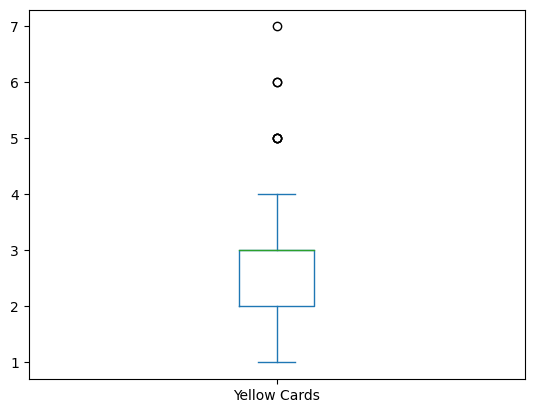

In [270]:

df[df['Ball Possession'] > 40].sort_values(by='Yellow Cards')['Yellow Cards'].plot(kind = 'box')

In [276]:
df[df['team'] == 'Brighton']

#When a game is selected, process corresponding charts of teams, referees

,team,Shots on Goal,Shots off Goal,Total Shots,Blocked Shots,Shots insidebox,Shots outsidebox,Fouls,Corner Kicks,Offsides,Ball Possession,Yellow Cards,Red Cards,Goalkeeper Saves,Total passes,Passes accurate,Passes %,expected_goals,fixtures,referee
6,Brighton,12,10.0,27,5.0,20,7.0,11,6.0,2.0,71,2.0,NaN,2.0,605,551,91%,4.01,1035040,D. Coote
37,Brighton,8,5.0,16,3.0,11,5.0,11,3.0,7.0,54,6.0,NaN,4.0,552,486,88%,2.22,1035056,A. Madley
44,Brighton,10,5.0,25,10.0,13,12.0,10,17.0,1.0,78,1.0,NaN,4.0,749,668,89%,1.48,1035060,A. Taylor
62,Brighton,6,5.0,15,4.0,9,6.0,14,5.0,5.0,56,4.0,NaN,2.0,565,507,90%,1.30,1035069,S. Attwell
85,Brighton,8,2.0,10,NaN,7,3.0,9,1.0,1.0,56,2.0,NaN,3.0,661,602,91%,1.70,1035081,J. Gillett
100,Brighton,4,3.0,13,6.0,8,5.0,12,4.0,1.0,62,3.0,NaN,2.0,519,449,87%,1.85,1035089,J. Brooks


In [ ]:
#NOTHING LIKE shots conceeded

In [247]:
import numpy as np

## Analysis by team

In [278]:
df.groupby('team').aggregate(sum).sort_values(by ='Goalkeeper Saves',ascending= False)

#add gw filter and last gws

/var/folders/3v/kl4z85b17kd84k1hy0srlb3w0000gn/T/ipykernel_1073/1819995749.py:1: FutureWarning: The operation <built-in function sum> failed on a column. If any error is raised, this will raise an exception in a future version of pandas. Drop these columns to avoid this warning.
  df.groupby('team').aggregate(sum).sort_values(by ='Goalkeeper Saves',ascending= False)


,Shots on Goal,Shots off Goal,Total Shots,Blocked Shots,Shots insidebox,Shots outsidebox,Fouls,Corner Kicks,Offsides,Ball Possession,Yellow Cards,Red Cards,Goalkeeper Saves,Total passes,Passes accurate
team,,,,,,,,,,,,,,,
Sheffield Utd,20,20.0,50,10.0,36,14.0,75,21.0,12.0,220,22.0,1.0,35.0,1990,1442
West Ham,26,26.0,66,14.0,49,17.0,68,25.0,15.0,212,17.0,1.0,30.0,2024,1566
Bournemouth,26,30.0,75,19.0,44,31.0,85,25.0,9.0,253,11.0,0.0,27.0,2180,1690
Wolves,22,31.0,76,23.0,55,21.0,77,19.0,12.0,283,18.0,2.0,26.0,2618,2133
Fulham,16,17.0,43,10.0,26,17.0,51,19.0,7.0,224,18.0,2.0,25.0,2102,1717
Tottenham,44,36.0,114,34.0,76,38.0,74,36.0,7.0,360,21.0,0.0,24.0,3382,2961
Manchester United,28,23.0,90,39.0,58,32.0,63,41.0,16.0,288,16.0,0.0,24.0,2864,2401
Liverpool,32,43.0,103,28.0,67,36.0,62,41.0,14.0,334,9.0,2.0,22.0,3429,2969
Nottingham Forest,20,25.0,62,17.0,35,27.0,70,23.0,14.0,219,21.0,1.0,20.0,2003,1526


## Analysis by referee

In [255]:
df.groupby('referee').aggregate(np.mean).sort_values(by ='Yellow Cards',ascending= False)

/var/folders/3v/kl4z85b17kd84k1hy0srlb3w0000gn/T/ipykernel_1073/2491261422.py:1: FutureWarning: The operation <function mean at 0x105810940> failed on a column. If any error is raised, this will raise an exception in a future version of pandas. Drop these columns to avoid this warning.
  df.groupby('referee').aggregate(np.mean).sort_values(by ='Yellow Cards',ascending= False)


,Shots on Goal,Shots off Goal,Total Shots,Blocked Shots,Shots insidebox,Shots outsidebox,Fouls,Corner Kicks,Offsides,Yellow Cards,Red Cards,Goalkeeper Saves,Total passes,Passes accurate
referee,,,,,,,,,,,,,,
P. Bankes,4.500000,5.375000,14.375000,4.500000,9.375000,5.000000,11.000000,7.250000,2.285714,3.833333,1.0,3.571429,431.125000,344.000000
C. Pawson,3.666667,4.500000,11.500000,3.333333,8.333333,3.166667,10.500000,5.800000,1.000000,3.750000,1.0,3.000000,463.333333,380.166667
D. England,5.750000,4.000000,14.750000,5.000000,8.750000,6.000000,11.500000,4.250000,1.333333,3.750000,NaN,3.250000,484.250000,403.000000
S. Attwell,6.000000,4.500000,13.750000,3.250000,9.250000,4.500000,11.625000,5.375000,3.285714,3.666667,1.0,4.125000,490.750000,410.375000
A. Madley,8.000000,4.250000,16.125000,3.875000,11.625000,4.500000,12.000000,5.500000,2.833333,3.375000,1.0,5.250000,478.750000,406.125000
A. Taylor,4.500000,3.600000,12.600000,4.500000,8.300000,4.300000,9.400000,6.900000,2.111111,3.200000,1.0,3.333333,493.700000,424.000000
D. Bond,5.000000,5.500000,13.500000,3.000000,9.500000,4.000000,12.500000,5.000000,2.500000,3.000000,1.0,3.500000,432.500000,360.500000
T. Robinson,3.500000,5.500000,14.000000,6.666667,8.250000,5.750000,12.000000,5.000000,2.666667,2.750000,NaN,2.750000,467.750000,391.000000
J. Brooks,4.875000,5.625000,14.750000,4.250000,9.375000,5.375000,13.125000,5.500000,1.714286,2.714286,1.0,3.375000,448.125000,366.000000


In [216]:
response.headers['X-RateLimit-requests-Remaining'] #Create slider, to visualize requests remaining, requests used for the day, versioning use of requests by minute

'26'

WEBSITE : https://www.api-football.com/documentation-v3#tag/Venues/operation/get-venues

In [ ]:
# Extract all team Ids and player Ids and competition Ids


## UTILS 

In [180]:
import json

def to_json(obj,fp):
    """obj is the object, fp is the filepath"""
    with open(fp, 'w') as out:
        json.dump(obj, out)

def from_json(fp):
    with open(fp, 'w') as ins:
        obj = json.load(ins)
    
    return obj
